---
format:
  html:
    toc: true
    toc-location: left
    toc-depth: 3
    number-sections: true
embed-resources: true
execute:
  echo: false
---

# Fourth-Down Decision Support Model for NFL Play-Calling

## Introduction

Fourth-down decisions are among the highest-leverage choices in football. When a team faces fourth down, the offense usually must decide whether to punt, attempt a field goal, or go for the conversion. Going for it can extend the drive and create a new scoring chance, but failure can hand the opponent possession with favorable field position. Because of that tradeoff, fourth-down decisions are a natural setting for probability-based modeling.

The goal of this project is to estimate the probability that a fourth-down attempt will be converted successfully. The model uses game-state information such as yards to go, distance from the opponent's end zone, play type, and selected team context. In practice, this type of model would be only one part of a larger decision-support system. A real fourth-down decision would also depend on score, time remaining, field-goal range, win probability, and other strategic considerations. Still, estimating conversion probability is a useful first step.

The response variable is `converted`, which records whether the fourth-down attempt succeeded. The main predictors include `togo`, `yardline`, `play_type`, `posteam`, and `defteam`. The variable `game_date` is used only to create time-based training and test sets so that model performance is evaluated on future games rather than on randomly mixed past and future plays.

## Data and Exploratory Data Analysis

### Analysis setup


In [1]:
# Standard libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Transformers & Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder, 
    StandardScaler, 
    TargetEncoder
)

# Models
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Model Selection & Validation
from sklearn.model_selection import (
    GridSearchCV, 
    RandomizedSearchCV, 
    TimeSeriesSplit, 
    train_test_split
)

# Metrics & Evaluation
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score, 
    brier_score_loss, 
    f1_score, 
    log_loss, 
    precision_score, 
    recall_score, 
    roc_auc_score, 
    roc_curve
)

### Data source

The data used in this project was acquired using the [nflreadpy](https://nflreadpy.nflverse.com/) package, which draws from the [nflverse-data repository](https://github.com/nflverse/nflverse-data).

The project uses a modified version of that source data. Each row represents one NFL fourth-down conversion attempt and includes the game date, field position, yards to go, play type, offensive team, defensive team, and whether the attempt was successful.

In [2]:
football = pd.read_parquet(
    "https://lab.cs307.org/football/data/football.parquet"
)

### Variable Descriptions


##### Response:

**`converted`**

- `[object]` result of fourth-down conversion attempt. One of `No` or `Yes`.

##### Features:

**`togo`**

- `[float64]` distance in yards from either the first down marker or the end zone in goal down situations. Distance needed to successfully convert the fourth-down attempt.

**`yardline`**

- `[float64]` distance in yards from the opponent's end zone. Distance needed to score a touchdown.

**`play_type`**

- `[object]` type of play. One of `Pass` or `Run`. Pass plays include sacks. Run plays include scrambles.

**`posteam`**

- `[object]` the abbreviation for the team with possession of the ball.

**`defteam`**

- `[object]` the abbreviation for the team on defense.

### Dataset overview

In [3]:
print("--- Dataset Shape ---")
print("Dataset shape: ", football.shape)

print("\n--- First 5 Rows ---")
display(football.head())

print("\n--- Dataset Info ---")
football.info()

print("\n--- `converted` Proportions ---")
display(football["converted"].value_counts(normalize=True).to_frame())

print("--- Game Date Range ---")
display(football['game_date'].agg(['min', 'max']))

--- Dataset Shape ---
Dataset shape:  (4553, 7)

--- First 5 Rows ---


,game_date,togo,yardline,converted,play_type,posteam,defteam
0,2019-09-08,5.0,20.0,Yes,Pass,ATL,MIN
1,2019-09-08,2.0,23.0,Yes,Pass,ATL,MIN
2,2019-09-08,1.0,70.0,Yes,Run,BAL,MIA
3,2019-09-08,3.0,3.0,Yes,Pass,BAL,MIA
4,2019-09-08,1.0,36.0,No,Run,BUF,NYJ



--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 4553 entries, 0 to 4552
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   game_date  4553 non-null   datetime64[ns]
 1   togo       4553 non-null   float64       
 2   yardline   4553 non-null   float64       
 3   converted  4553 non-null   category      
 4   play_type  4553 non-null   category      
 5   posteam    4553 non-null   str           
 6   defteam    4553 non-null   str           
dtypes: category(2), datetime64[ns](1), float64(2), str(2)
memory usage: 211.4 KB

--- `converted` Proportions ---


,proportion
converted,
Yes,0.529321
No,0.470679


--- Game Date Range ---


min   2019-09-05
max   2025-02-09
Name: game_date, dtype: datetime64[ns]

The dataset contains 4,553 fourth-down conversion attempts from 2019 to early 2025. There were no missing values in the main variables used for modeling. Overall, 52.9% of fourth-down attempts in the dataset were successful. This means the response variable is fairly balanced, although successful attempts are slightly more common than failed attempts.

### Response encoding

To fit classification models, the response is converted from `Yes` and `No` into a binary 1/0 indicator. The original categorical outcome is kept for interpretation, while the numeric version is used in the modeling pipeline.

In [4]:
football["converted_binary"] = football["converted"].map({
    "Yes": 1,
    "No": 0
})

### Conversion success by yards to go

The grouped summary and @fig-eda-conversion-rate show a strong distance effect. Fourth-and-1 situations convert about 67.3% of the time, while attempts needing 11 or more yards convert only about 18.5% of the time. This pattern strongly suggests that the relationship between distance and success is not flat, which motivates the grouped distance features created later in the report.

,distance_group,n,conversion_rate
0,1 yard,1799,0.672596
1,2 yards,672,0.574405
2,3 yards,406,0.509852
3,4-5 yards,600,0.485000
4,6-10 yards,703,0.351351
5,11+ yards,373,0.184987


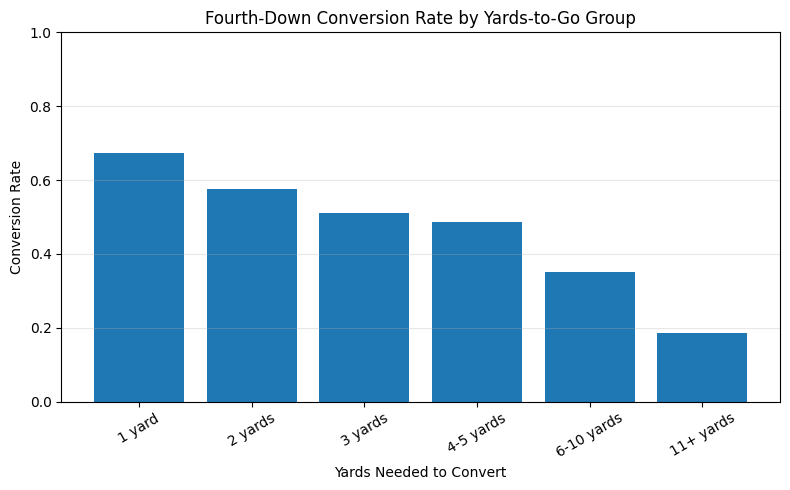

In [5]:
#| label: fig-eda-conversion-rate
#| fig-cap: "Observed fourth-down conversion rate by yards-to-go group. Conversion success declines sharply as the distance needed increases."
football_eda = football.copy()

football_eda["converted_binary"] = football_eda["converted"].map({
    "Yes": 1,
    "No": 0
})
football_eda["converted_binary"] = football_eda["converted_binary"].astype(int)

football_eda["distance_group"] = pd.cut(
    football_eda["togo"],
    bins=[0, 1, 2, 3, 5, 10, 100],
    labels=["1 yard", "2 yards", "3 yards", "4-5 yards", "6-10 yards", "11+ yards"],
    include_lowest=True
)
distance_summary = (
    football_eda
    .groupby("distance_group", observed=False)
    .agg(
        n=("converted_binary", "size"),
        conversion_rate=("converted_binary", "mean")
    )
    .reset_index()
)

display(distance_summary)

plt.figure(figsize=(8, 5))
plt.bar(
    distance_summary["distance_group"].astype(str),
    distance_summary["conversion_rate"]
)

plt.xlabel("Yards Needed to Convert")
plt.ylabel("Conversion Rate")
plt.title("Fourth-Down Conversion Rate by Yards-to-Go Group")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

The grouped summary and @fig-eda-conversion-rate show a strong distance effect. Fourth-and-1 situations convert about 67.3% of the time, while attempts needing 11 or more yards convert only about 18.5% of the time. This pattern strongly suggests that the relationship between distance and success is not flat, which motivates the grouped distance features created later in the report.

## Feature Engineering

The raw variables already contain useful information, but football strategy is often easier to model through context-specific features. To better represent game situations, I created indicators for the red zone and goal-to-go plays, grouped distance and field-position categories, and interaction features that combine play type with yards to go.

### Create football-specific features

This setup step creates a self-contained feature-engineering dataset, ensures that `game_date` is stored as a datetime variable, and rebuilds the binary response inside that working copy.

In [6]:
football_fe = football.copy()

football_fe["game_date"] = pd.to_datetime(football_fe["game_date"])

football_fe["converted_binary"] = football_fe["converted"].map({
    "Yes": 1,
    "No": 0
}).astype(int)

I created several engineered features to make the model better reflect football strategy. First, I created a red zone indicator for plays within 20 yards of the opponent's end zone, since play-calling and defensive strategy may change near the end zone. I also created a goal-to-go indicator to identify plays where the offense needed to reach the end zone rather than simply gain a new first down. In addition, I grouped yards-to-go into short, medium, and long distance categories because fourth-and-1 and fourth-and-8 represent very different conversion situations. I also created a field position group to separate red zone plays, opponent territory plays, and own territory plays. Finally, I created a yards-to-go to yardline ratio and a pass-distance interaction variable to help the model capture how distance and play type work together.

In [7]:
# # Red zone indicator

football_fe["red_zone"] = (football_fe["yardline"] <= 20).astype(int)


# Goal-to-go indicator
# If togo >= yeardline, meaning first down marker is close to pass the end zone, that is goal togo.
football_fe["goal_to_go"] = (football_fe["togo"] >= football_fe["yardline"]).astype(int)


# I created a distance group variable because fourth-down attempts have different strategic meanings depending 
# on the yards needed. Short-yardage attempts are usually easier to convert than long-yardage attempts.
football_fe["distance_group"] = pd.cut(
    football_fe["togo"],
    bins=[0, 2, 5, np.inf],
    labels=["short_1_2", "medium_3_5", "long_6_plus"]
)


# Field position category
# Failing in your own half can give the opponent excellent field position.
# Failing in the opponent’s half carries relatively less risk.
# In the red zone, the stakes are different whether you succeed or fail.
football_fe["field_position_group"] = np.select(
    [
        football_fe["yardline"] <= 20,
        football_fe["yardline"] <= 50,
        football_fe["yardline"] > 50
    ],
    [
        "red_zone",
        "opponent_territory",
        "own_territory"
    ],
    default="unknown"
)
football_fe["field_position_group"] = football_fe["field_position_group"].astype("category")

# Ratio of yards-to-go relative to distance from end zone; 
# It combines two pieces of information: How many yards are needed for a first down; How far away from the end zone
football_fe["togo_yardline_ratio"] = football_fe["togo"] / football_fe["yardline"].clip(lower=1)

# Pass interaction feature; 
# pass_play is a boolean variable, pass = 1, run = 0. 
football_fe["pass_play"] = (football_fe["play_type"] == "Pass").astype(int)

football_fe["pass_togo"] = football_fe["togo"] * football_fe["pass_play"]

These engineered features translate football context into model inputs. Red-zone and goal-to-go indicators capture field context, grouped distance and field-position variables allow for non-linear situation effects, and the ratio and interaction terms let the model combine distance with play type more directly.

### Check engineered features

The next outputs verify that the engineered columns were created correctly and summarize how the new grouped variables relate to conversion success.

@tbl-feature-preview confirms that the engineered dataset contains the intended mix of binary indicators, grouped categories, and interaction terms. Keeping this preview in the report helps a reader understand exactly what information is available to the later models when the code is hidden.

In [8]:
#| label: tbl-feature-preview
#| tbl-cap: "Preview of the engineered feature set used in later models."
football_fe[
    [
        "converted",
        "converted_binary",
        "togo",
        "yardline",
        "play_type",
        "red_zone",
        "goal_to_go",
        "distance_group",
        "field_position_group",
        "togo_yardline_ratio",
        "pass_play",
        "pass_togo"
    ]
].head(10)

,converted,converted_binary,togo,yardline,play_type,red_zone,goal_to_go,distance_group,field_position_group,togo_yardline_ratio,pass_play,pass_togo
0,Yes,1,5.0,20.0,Pass,1,0,medium_3_5,red_zone,0.250000,1,5.0
1,Yes,1,2.0,23.0,Pass,0,0,short_1_2,opponent_territory,0.086957,1,2.0
2,Yes,1,1.0,70.0,Run,0,0,short_1_2,own_territory,0.014286,0,0.0
3,Yes,1,3.0,3.0,Pass,1,1,medium_3_5,red_zone,1.000000,1,3.0
4,No,0,1.0,36.0,Run,0,0,short_1_2,opponent_territory,0.027778,0,0.0
5,Yes,1,1.0,66.0,Run,0,0,short_1_2,own_territory,0.015152,0,0.0
6,No,0,10.0,60.0,Pass,0,0,long_6_plus,own_territory,0.166667,1,10.0
7,No,0,1.0,36.0,Run,0,0,short_1_2,opponent_territory,0.027778,0,0.0
8,No,0,24.0,90.0,Pass,0,0,long_6_plus,own_territory,0.266667,1,24.0
9,No,0,10.0,33.0,Run,0,0,long_6_plus,opponent_territory,0.303030,0,0.0


@tbl-distance-group-summary preserves the same pattern seen in the earlier EDA: short-yardage attempts convert at the highest rate, medium-distance attempts are roughly coin-flip situations, and long-yardage attempts convert much less often. This supports the decision to keep grouped distance as a modeling feature.

In [9]:
#| label: tbl-distance-group-summary
#| tbl-cap: "Observed conversion rate by engineered distance group."
football_fe.groupby("distance_group")["converted_binary"].agg(["count", "mean"])

,count,mean
distance_group,,
short_1_2,2471,0.645892
medium_3_5,1006,0.495030
long_6_plus,1076,0.293680


@tbl-field-position-summary shows that field position matters, although the differences are smaller than the differences by yards to go. Conversion rates are slightly lower in a team's own territory than in opponent territory or the red zone, which suggests that field context may still contribute useful signal when combined with other variables.

In [10]:
#| label: tbl-field-position-summary
#| tbl-cap: "Observed conversion rate by engineered field-position group."
football_fe.groupby("field_position_group")["converted_binary"].agg(["count", "mean"])

,count,mean
field_position_group,,
opponent_territory,2170,0.539171
own_territory,1275,0.504314
red_zone,1108,0.538809


Run plays convert more often than pass plays in this sample, which helps justify keeping `play_type` and the pass-by-distance interaction in the feature set. Together, the engineered summaries in this section show that the new variables capture meaningful football structure rather than arbitrary transformations.

In [11]:
#| label: tbl-play-type-summary
#| tbl-cap: "Observed conversion rate by play type."
football_fe.groupby("play_type")["converted_binary"].agg(["count", "mean"])

,count,mean
play_type,,
Pass,2824,0.436615
Run,1729,0.680740


## Model Building

This section develops a sequence of models. It starts with a simple baseline logistic regression and then compares richer models that use the engineered football features.

### Baseline logistic regression

The baseline model uses the original variables only: `togo`, `yardline`, `play_type`, `posteam`, and `defteam`. The data split is time-based (train set contains dates before 01/01/2024, test set contains dates afterward.) so the model is trained on earlier seasons and evaluated on later games, which better matches how the model would be used in practice.

In [12]:
np.random.seed(42)
train = football[football["game_date"] < "2024-01-01"].copy()
test = football[football["game_date"] >= "2024-01-01"].copy()

X_train = train[["togo", "yardline", "play_type", "posteam", "defteam"]]
y_train = train["converted_binary"]

X_test = test[["togo", "yardline", "play_type", "posteam", "defteam"]]
y_test = test["converted_binary"]

print(train.shape)
print(test.shape)

(3652, 8)
(901, 8)


The baseline split produces 3,652 training plays and 901 test plays. Keeping the split chronological prevents future-game information from leaking into model development.

### Baseline preprocessing and fitting

Numeric predictors are standardized and categorical predictors are one-hot encoded before logistic regression is fit. This creates a transparent reference model against which later feature-engineered and non-linear models can be compared.

In [13]:
numeric_features = ["togo", "yardline"]
categorical_features = ["play_type", "posteam", "defteam"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

log_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

log_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [14]:
pred_class = log_model.predict(X_test)
pred_prob = log_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, pred_class))
print("ROC-AUC:", roc_auc_score(y_test, pred_prob))
print("Log Loss:", log_loss(y_test, pred_prob))
print("Brier Score:", brier_score_loss(y_test, pred_prob))

Accuracy: 0.6281908990011099
ROC-AUC: 0.6698518920439701
Log Loss: 0.6365436959172184
Brier Score: 0.22347626775882729


On the held-out future-season test set, the baseline logistic regression reaches 0.628 accuracy, 0.670 ROC-AUC, 0.637 log loss, and 0.223 Brier score. These results show that the raw variables contain useful predictive signal, but they also leave room for improvement in both discrimination and probability accuracy.

### Baseline diagnostic plots

The next two diagnostics evaluate the baseline model from two angles: discrimination through the ROC curve and calibration through the agreement between predicted and observed probabilities.

@fig-baseline-roc-curve shows that the baseline model performs better than random guessing, but only with moderate separation between successful and unsuccessful attempts. That makes it a useful reference point rather than a final decision model.

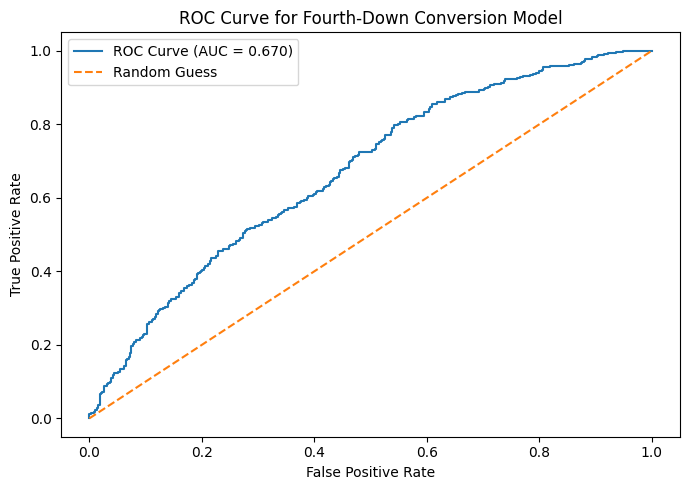

In [15]:
#| label: fig-baseline-roc-curve
#| fig-cap: "ROC curve for the baseline logistic regression model on the future-season test set."
pred_prob = log_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, pred_prob)
auc = roc_auc_score(y_test, pred_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Fourth-Down Conversion Model")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=300)
plt.show()

@fig-baseline-calibration-curve suggests that the baseline probabilities are reasonably aligned with observed outcomes, especially in the middle and upper probability ranges. However, some instability remains at the low end, which is another reason to test richer feature sets and alternative models.

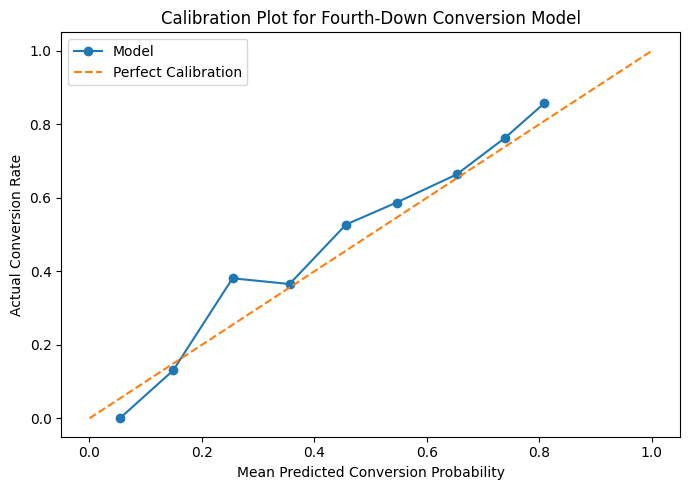

In [16]:
#| label: fig-baseline-calibration-curve
#| fig-cap: "Calibration plot for the baseline logistic regression model on the future-season test set."
prob_true, prob_pred = calibration_curve(y_test, pred_prob, n_bins=10)

plt.figure(figsize=(7, 5))
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")

plt.xlabel("Mean Predicted Conversion Probability")
plt.ylabel("Actual Conversion Rate")
plt.title("Calibration Plot for Fourth-Down Conversion Model")
plt.legend()
plt.tight_layout()
plt.savefig("calibration_plot.png", dpi=300)
plt.show()

### Feature-engineered candidate models

After establishing the baseline, the analysis compares models that use the football-specific engineered features created earlier. The main goal is to improve out-of-sample probability quality, so log loss and Brier score are treated as the most important selection metrics.

In [17]:
# Make categorical engineered variables safe for OneHotEncoder
categorical_clean_cols = [
    "play_type",
    "distance_group",
    "field_position_group",
    "posteam",
    "defteam"
]

for col in categorical_clean_cols:
    football_fe[col] = football_fe[col].astype("object").fillna("unknown")

This preparation step makes the categorical engineered variables safe for consistent encoding across all later pipelines by converting them to plain text and filling any missing category with `unknown`.

In [18]:
# Time-based split
train_fe = football_fe[football_fe["game_date"] < pd.Timestamp("2024-01-01")].copy()
test_fe = football_fe[football_fe["game_date"] >= pd.Timestamp("2024-01-01")].copy()

y_train_fe = train_fe["converted_binary"]
y_test_fe = test_fe["converted_binary"]

print("Train shape:", train_fe.shape)
print("Test shape:", test_fe.shape)

Train shape: (3652, 15)
Test shape: (901, 15)


The engineered dataset keeps the same chronological split as the baseline model while expanding the number of available predictors with the new football-context features.

### Including versus excluding team identifiers

Team identifiers may capture useful context, but they also introduce many categories relative to the size of the dataset. Because roster strength, coaching, and play-calling tendencies change across seasons, a model with team labels may overfit historical patterns. The following comparisons test both specifications directly.

In [19]:
# Feature-engineered model WITHOUT team variables

numeric_features_fe_no_team = [
    "togo",
    "yardline",
    "red_zone",
    "goal_to_go",
    "togo_yardline_ratio",
    "pass_togo"
]

categorical_features_fe_no_team = [
    "play_type",
    "distance_group",
    "field_position_group"
]


# Feature-engineered model WITH team variables

numeric_features_fe_with_team = numeric_features_fe_no_team.copy()

categorical_features_fe_with_team = categorical_features_fe_no_team + [
    "posteam",
    "defteam"
]

### Logistic regression pipeline for engineered features

A reusable pipeline keeps preprocessing and fitting consistent across the engineered logistic regression models.

In [20]:
def make_logistic_pipeline(numeric_features, categorical_features, C=1.0):
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
        ]
    )
    
    model = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", LogisticRegression(max_iter=2000, C=C))
        ]
    )
    
    return model

### Common evaluation function

The next function fits a model on the training period and evaluates it on the held-out test period using the same set of classification and probability metrics throughout the report.

In [21]:
def evaluate_model(model_name, team_variables, model, train_df, test_df,
                   numeric_features, categorical_features):
    
    feature_cols = numeric_features + categorical_features
    
    X_train = train_df[feature_cols]
    X_test = test_df[feature_cols]
    
    model.fit(X_train, y_train_fe)
    
    pred_class = model.predict(X_test)
    pred_prob = model.predict_proba(X_test)[:, 1]
    
    results = {
        "Model": model_name,
        "Team Variables": team_variables,
        "Accuracy": accuracy_score(y_test_fe, pred_class),
        "ROC-AUC": roc_auc_score(y_test_fe, pred_prob),
        "Log Loss": log_loss(y_test_fe, pred_prob),
        "Brier Score": brier_score_loss(y_test_fe, pred_prob),
        "Precision": precision_score(y_test_fe, pred_class, zero_division=0),
        "Recall": recall_score(y_test_fe, pred_class, zero_division=0),
        "F1": f1_score(y_test_fe, pred_class, zero_division=0)
    }
    
    return results, model, pred_prob

### Compare logistic regression with and without team identifiers

These two models use the same engineered features, differing only in whether the offensive and defensive team labels are included.

In [22]:
# Logistic Regression WITHOUT team variables
log_fe_no_team = make_logistic_pipeline(
    numeric_features_fe_no_team,
    categorical_features_fe_no_team
)

results_no_team, log_fe_no_team, pred_prob_no_team = evaluate_model(
    model_name="Feature-Engineered Logistic Regression",
    team_variables="No",
    model=log_fe_no_team,
    train_df=train_fe,
    test_df=test_fe,
    numeric_features=numeric_features_fe_no_team,
    categorical_features=categorical_features_fe_no_team
)


# Logistic Regression WITH team variables
log_fe_with_team = make_logistic_pipeline(
    numeric_features_fe_with_team,
    categorical_features_fe_with_team
)

results_with_team, log_fe_with_team, pred_prob_with_team = evaluate_model(
    model_name="Feature-Engineered Logistic Regression",
    team_variables="Yes",
    model=log_fe_with_team,
    train_df=train_fe,
    test_df=test_fe,
    numeric_features=numeric_features_fe_with_team,
    categorical_features=categorical_features_fe_with_team
)

In [23]:
#| label: tbl-logistic-comparison
#| tbl-cap: "Comparison of feature-engineered logistic regression models with and without team identifiers."
logistic_comparison = pd.DataFrame([
    results_no_team,
    results_with_team,
])

logistic_comparison = logistic_comparison.sort_values(
    by="Log Loss",
    ascending=True
)

display(logistic_comparison.round(4))

,Model,Team Variables,Accuracy,ROC-AUC,Log Loss,Brier Score,Precision,Recall,F1
0,Feature-Engineered Logistic Regression,No,0.6593,0.6912,0.6265,0.2186,0.6907,0.7271,0.7085
1,Feature-Engineered Logistic Regression,Yes,0.6293,0.6752,0.6351,0.2227,0.6679,0.6940,0.6807


Table @tbl-logistic-comparison shows that the feature-engineered logistic regression without team identifiers performs best across the core probability metrics. Its log loss falls to 0.6265 and its Brier score to 0.2186, both better than the version with team labels. This suggests that team identifiers add noise rather than stable predictive signal for future-season prediction.

### Random forest candidates

A random forest with target encoding is tested to see whether a non-linear model can improve fourth-down conversion probabilities beyond logistic regression. Target encoding is especially helpful when team identifiers are included because it summarizes many categories without creating a large sparse design matrix.

In [24]:
def make_rf_target_pipeline(numeric_features, categorical_features):
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                SimpleImputer(strategy="median"),
                numeric_features
            ),
            (
                "cat_target",
                TargetEncoder(
                    smooth="auto",
                    target_type="binary",
                    random_state=42
                ),
                categorical_features
            )
        ]
    )
    
    model = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", RandomForestClassifier(
                n_estimators=500,
                max_depth=None,
                min_samples_leaf=20,
                max_features="sqrt",
                random_state=42,
                n_jobs=-1
            ))
        ]
    )
    
    return model

In [25]:
# Random Forest WITHOUT team variables
rf_target_no_team = make_rf_target_pipeline(
    numeric_features_fe_no_team,
    categorical_features_fe_no_team
)

results_rf_no_team, rf_target_no_team, pred_prob_rf_no_team = evaluate_model(
    model_name="Random Forest with Target Encoding",
    team_variables="No",
    model=rf_target_no_team,
    train_df=train_fe,
    test_df=test_fe,
    numeric_features=numeric_features_fe_no_team,
    categorical_features=categorical_features_fe_no_team
)

# Random Forest WITH team variables
rf_target_with_team = make_rf_target_pipeline(
    numeric_features_fe_with_team,
    categorical_features_fe_with_team
)

results_rf_with_team, rf_target_with_team, pred_prob_rf_with_team = evaluate_model(
    model_name="Random Forest with Target Encoding",
    team_variables="Yes",
    model=rf_target_with_team,
    train_df=train_fe,
    test_df=test_fe,
    numeric_features=numeric_features_fe_with_team,
    categorical_features=categorical_features_fe_with_team
)

In [26]:
#| label: tbl-logistic-rf-comparison
#| tbl-cap: "Comparison of the leading logistic regression and random forest candidate models."
rf_comparison = pd.DataFrame([
    results_rf_no_team,
    results_rf_with_team
])

model_comparison = pd.concat(
    [
        logistic_comparison,
        rf_comparison
    ],
    ignore_index=True
)

model_comparison = model_comparison.sort_values(
    by="Log Loss",
    ascending=True
)

display(model_comparison.round(4))

,Model,Team Variables,Accuracy,ROC-AUC,Log Loss,Brier Score,Precision,Recall,F1
0,Feature-Engineered Logistic Regression,No,0.6593,0.6912,0.6265,0.2186,0.6907,0.7271,0.7085
3,Random Forest with Target Encoding,Yes,0.6482,0.6874,0.6303,0.2199,0.6756,0.7349,0.7040
2,Random Forest with Target Encoding,No,0.6371,0.6820,0.6334,0.2214,0.6643,0.7329,0.6969
1,Feature-Engineered Logistic Regression,Yes,0.6293,0.6752,0.6351,0.2227,0.6679,0.6940,0.6807


Adding random forest candidates narrows the gap, but the best random forest still trails the no-team logistic model on log loss and Brier score. At this stage, the extra flexibility of the forest does not outweigh the logistic model's stronger probability accuracy.

### Histgradient boosting candidates

A histogram-based gradient boosting classifier with target encoding is also evaluated.

In [27]:
def make_hgb_target_pipeline(numeric_features, categorical_features):
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                SimpleImputer(strategy="median"),
                numeric_features
            ),
            (
                "cat_target",
                TargetEncoder(
                    smooth="auto",
                    target_type="binary",
                    random_state=42
                ),
                categorical_features
            )
        ]
    )
    
    model = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", HistGradientBoostingClassifier(
                max_iter=300,
                max_features=0.5,
                learning_rate=0.25,
                max_leaf_nodes=15,
                min_samples_leaf=25,
                random_state=42,
                l2_regularization=0.1,
                early_stopping=True,
                validation_fraction=0.15,
            ))
        ]
    )
    
    return model

In [28]:
# Gradient Boosting WITHOUT team variables
hgb_target_no_team = make_hgb_target_pipeline(
    numeric_features_fe_no_team,
    categorical_features_fe_no_team
)

results_hgb_no_team, hgb_target_no_team, pred_prob_hgb_no_team = evaluate_model(
    model_name="HistGradientBoosting with Target Encoding",
    team_variables="No",
    model=hgb_target_no_team,
    train_df=train_fe,
    test_df=test_fe,
    numeric_features=numeric_features_fe_no_team,
    categorical_features=categorical_features_fe_no_team
)

# Gradient Boosting WITH team variables
hgb_target_with_team = make_hgb_target_pipeline(
    numeric_features_fe_with_team,
    categorical_features_fe_with_team
)

results_hgb_with_team, hgb_target_with_team, pred_prob_hgb_with_team = evaluate_model(
    model_name="HistGradientBoosting with Target Encoding",
    team_variables="Yes",
    model=hgb_target_with_team,
    train_df=train_fe,
    test_df=test_fe,
    numeric_features=numeric_features_fe_with_team,
    categorical_features=categorical_features_fe_with_team
)

In [29]:
#| label: tbl-initial-model-comparison
#| tbl-cap: "Initial comparison of all engineered candidate models before hyperparameter tuning."
hgb_comparison = pd.DataFrame([
    results_hgb_no_team,
    results_hgb_with_team
])

model_comparison = pd.concat(
    [
        model_comparison,
        hgb_comparison
    ],
    ignore_index=True
)

model_comparison = model_comparison.sort_values(
    by="Log Loss",
    ascending=True
)

display(model_comparison.round(4))

,Model,Team Variables,Accuracy,ROC-AUC,Log Loss,Brier Score,Precision,Recall,F1
0,Feature-Engineered Logistic Regression,No,0.6593,0.6912,0.6265,0.2186,0.6907,0.7271,0.7085
1,Random Forest with Target Encoding,Yes,0.6482,0.6874,0.6303,0.2199,0.6756,0.7349,0.7040
2,Random Forest with Target Encoding,No,0.6371,0.6820,0.6334,0.2214,0.6643,0.7329,0.6969
3,Feature-Engineered Logistic Regression,Yes,0.6293,0.6752,0.6351,0.2227,0.6679,0.6940,0.6807
5,HistGradientBoosting with Target Encoding,Yes,0.6337,0.6754,0.6369,0.2230,0.6631,0.7251,0.6927
4,HistGradientBoosting with Target Encoding,No,0.6304,0.6707,0.6401,0.2247,0.6724,0.6842,0.6783


Across the initial comparison in @tbl-initial-model-comparison, the feature-engineered logistic regression without team variables remains the strongest candidate. It has the lowest log loss and Brier score, which are the most relevant measures for a model whose main job is to output useful probabilities rather than only hard classifications.

### Validation-based tuning

The leading models are tuned with time-series cross-validation so that hyperparameters are selected using past-to-future validation splits instead of random folds. This keeps the tuning strategy aligned with the forecasting goal of the project.

In [30]:
train_fe_cv = train_fe.sort_values("game_date").reset_index(drop=True)
test_fe_cv = test_fe.sort_values("game_date").reset_index(drop=True)

y_train_cv = train_fe_cv["converted_binary"]
y_test_cv = test_fe_cv["converted_binary"]

tscv = TimeSeriesSplit(n_splits=5)

The training data are sorted by date and evaluated with five rolling validation splits. Each fold predicts later plays from earlier ones, which is more appropriate than random cross-validation for this problem.

In [31]:
# A second evaluation helper is defined below so tuned models can be scored on the held-out test set 
# using the same metrics as the earlier untuned comparisons.

def evaluate_fitted_model(model_name, team_variables, fitted_model, X_test, y_test):
    pred_class = fitted_model.predict(X_test)
    pred_prob = fitted_model.predict_proba(X_test)[:, 1]
    
    return {
        "Model": model_name,
        "Team Variables": team_variables,
        "Accuracy": accuracy_score(y_test, pred_class),
        "ROC-AUC": roc_auc_score(y_test, pred_prob),
        "Log Loss": log_loss(y_test, pred_prob),
        "Brier Score": brier_score_loss(y_test, pred_prob),
        "Precision": precision_score(y_test, pred_class, zero_division=0),
        "Recall": recall_score(y_test, pred_class, zero_division=0),
        "F1": f1_score(y_test, pred_class, zero_division=0)
    }, pred_prob

### Tune the leading logistic regression model

The next cells prepare the feature matrix, search over regularization strength and class weighting, and then evaluate the best tuned logistic model on the held-out test set.

In [32]:
X_train_log_no_team = train_fe_cv[
    numeric_features_fe_no_team + categorical_features_fe_no_team
]

X_test_log_no_team = test_fe_cv[
    numeric_features_fe_no_team + categorical_features_fe_no_team
]

In [33]:
log_no_team_for_cv = make_logistic_pipeline(
    numeric_features_fe_no_team,
    categorical_features_fe_no_team
)

log_param_grid = {
    "model__C": [0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10],
    "model__class_weight": [None, "balanced"]
}

log_cv = GridSearchCV(
    estimator=log_no_team_for_cv,
    param_grid=log_param_grid,
    scoring={
        "neg_log_loss": "neg_log_loss",
        "neg_brier_score": "neg_brier_score",
        "roc_auc": "roc_auc"
    },
    refit="neg_log_loss",
    cv=tscv,
    n_jobs=-1,
    verbose=1
)

log_cv.fit(X_train_log_no_team, y_train_cv)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=2000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.05, ...], 'model__class_weight': [None, 'balanced']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'neg_brier_score': 'neg_brier_score', 'neg_log_loss': 'neg_log_loss', 'roc_auc': 'roc_auc'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'neg_log_loss'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the h

In [34]:
print("Best Logistic Parameters:")
print(log_cv.best_params_)

print("Best CV Log Loss:")
print(-log_cv.best_score_)

Best Logistic Parameters:
{'model__C': 0.5, 'model__class_weight': 'balanced'}
Best CV Log Loss:
0.6354826736686906


The best cross-validated logistic model uses `C = 0.5` with balanced class weights. Because the search is refit on negative log loss, these settings are chosen to improve probability quality rather than classification rate alone.

In [35]:
#| label: tbl-tuned-logistic
#| tbl-cap: "Held-out test performance of the tuned logistic regression model."
best_log_no_team = log_cv.best_estimator_

results_tuned_log_no_team, pred_prob_tuned_log_no_team = evaluate_fitted_model(
    model_name="Tuned Logistic Regression",
    team_variables="No",
    fitted_model=best_log_no_team,
    X_test=X_test_log_no_team,
    y_test=y_test_cv
)

display(pd.DataFrame([results_tuned_log_no_team]).round(4))

,Model,Team Variables,Accuracy,ROC-AUC,Log Loss,Brier Score,Precision,Recall,F1
0,Tuned Logistic Regression,No,0.6448,0.6913,0.6299,0.2201,0.6918,0.6784,0.685


@tbl-tuned-logistic shows that tuning preserves ROC-AUC but slightly worsens log loss and Brier score on the held-out test set compared with the untuned no-team logistic model. Tuning therefore does not replace the simpler feature-engineered logistic model as the leading candidate.

### Tune a strong random forest benchmark

A tuned random forest with team identifiers is retained as the main non-linear benchmark because it was the strongest forest specification in the earlier comparison.

In [36]:
X_train_rf_with_team = train_fe_cv[
    numeric_features_fe_with_team + categorical_features_fe_with_team
]

X_test_rf_with_team = test_fe_cv[
    numeric_features_fe_with_team + categorical_features_fe_with_team
]

In [37]:
rf_with_team_for_cv = make_rf_target_pipeline(
    numeric_features_fe_with_team,
    categorical_features_fe_with_team
)

rf_param_dist = {
    "model__n_estimators": [300, 500, 800],
    "model__max_depth": [3, 5, 8, 12, None],
    "model__min_samples_leaf": [5, 10, 20, 40, 60],
    "model__max_features": ["sqrt", 0.5, 0.75, None],
    "model__class_weight": [None, "balanced"]
}

rf_cv = RandomizedSearchCV(
    estimator=rf_with_team_for_cv,
    param_distributions=rf_param_dist,
    n_iter=25,
    scoring={
        "neg_log_loss": "neg_log_loss",
        "neg_brier_score": "neg_brier_score",
        "roc_auc": "roc_auc"
    },
    refit="neg_log_loss",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_cv.fit(X_train_rf_with_team, y_train_cv)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


/home/ytan48/cs307/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__class_weight': [None, 'balanced'], 'model__max_depth': [3, 5, ...], 'model__max_features': ['sqrt', 0.5, ...], 'model__min_samples_leaf': [5, 10, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'neg_brier_score': 'neg_brier_score', 'neg_log_loss': 'neg_log_loss', 'roc_auc': 'roc_auc'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'neg_log_loss'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so th

In [38]:
print("Best Random Forest Parameters:")
print(rf_cv.best_params_)

print("Best CV Log Loss:")
print(-rf_cv.best_score_)

Best Random Forest Parameters:
{'model__n_estimators': 800, 'model__min_samples_leaf': 20, 'model__max_features': 'sqrt', 'model__max_depth': 5, 'model__class_weight': 'balanced'}
Best CV Log Loss:
0.6413481042761594


The best random forest uses 800 trees, shallow depth 5, a minimum leaf size of 20, square-root feature sampling, and balanced class weights. These settings favor stability over highly flexible trees.

In [39]:
#| label: tbl-tuned-random-forest
#| tbl-cap: "Held-out test performance of the tuned random forest benchmark."
best_rf_with_team = rf_cv.best_estimator_

results_tuned_rf_with_team, pred_prob_tuned_rf_with_team = evaluate_fitted_model(
    model_name="Tuned Random Forest with Target Encoding",
    team_variables="Yes",
    fitted_model=best_rf_with_team,
    X_test=X_test_rf_with_team,
    y_test=y_test_cv
)

display(pd.DataFrame([results_tuned_rf_with_team]).round(4))

,Model,Team Variables,Accuracy,ROC-AUC,Log Loss,Brier Score,Precision,Recall,F1
0,Tuned Random Forest with Target Encoding,Yes,0.6415,0.6935,0.6313,0.2204,0.6827,0.692,0.6873


Table @tbl-tuned-random-forest shows that the tuned random forest achieves the highest ROC-AUC among the tuned candidates, but its log loss and Brier score remain worse than the leading logistic model. For this project, that keeps it as a useful benchmark rather than the final selection.

## Model Evaluation and Results

### Final model comparison

This section consolidates the earlier comparisons and evaluates the final selected model in more detail.

In [40]:
#| label: tbl-final-model-comparison
#| tbl-cap: "Final comparison of untuned and tuned candidate models on the held-out test set."
tuned_comparison = pd.DataFrame([
    results_tuned_log_no_team,
    results_tuned_rf_with_team
])

final_model_comparison = pd.concat(
    [
        model_comparison,
        tuned_comparison
    ],
    ignore_index=True
)

final_model_comparison = final_model_comparison.sort_values(
    by="Log Loss",
    ascending=True
)

display(final_model_comparison.round(4))

,Model,Team Variables,Accuracy,ROC-AUC,Log Loss,Brier Score,Precision,Recall,F1
0,Feature-Engineered Logistic Regression,No,0.6593,0.6912,0.6265,0.2186,0.6907,0.7271,0.7085
6,Tuned Logistic Regression,No,0.6448,0.6913,0.6299,0.2201,0.6918,0.6784,0.6850
1,Random Forest with Target Encoding,Yes,0.6482,0.6874,0.6303,0.2199,0.6756,0.7349,0.7040
7,Tuned Random Forest with Target Encoding,Yes,0.6415,0.6935,0.6313,0.2204,0.6827,0.6920,0.6873
2,Random Forest with Target Encoding,No,0.6371,0.6820,0.6334,0.2214,0.6643,0.7329,0.6969
3,Feature-Engineered Logistic Regression,Yes,0.6293,0.6752,0.6351,0.2227,0.6679,0.6940,0.6807
4,HistGradientBoosting with Target Encoding,Yes,0.6337,0.6754,0.6369,0.2230,0.6631,0.7251,0.6927
5,HistGradientBoosting with Target Encoding,No,0.6304,0.6707,0.6401,0.2247,0.6724,0.6842,0.6783


@tbl-final-model-comparison shows that the original feature-engineered logistic regression without team identifiers remains the strongest model for probability estimation. Even though the tuned random forest posts the highest ROC-AUC, it has worse log loss and Brier score than the logistic model. Because this project prioritizes reliable probabilities, the no-team logistic model is the most appropriate final choice.

### Final model refit and baseline comparison

The final selected model is refit on the full training period using the chosen feature set. The following output then compares its Brier score with a naive baseline that always predicts the training-set conversion rate.

In [41]:
# Final selected model: Feature-Engineered Logistic Regression without team variables

final_model = make_logistic_pipeline(
    numeric_features_fe_no_team,
    categorical_features_fe_no_team
)

X_train_final = train_fe[numeric_features_fe_no_team + categorical_features_fe_no_team]
X_test_final = test_fe[numeric_features_fe_no_team + categorical_features_fe_no_team]

y_train_final = train_fe["converted_binary"]
y_test_final = test_fe["converted_binary"]

final_model.fit(X_train_final, y_train_final)

final_pred_class = final_model.predict(X_test_final)
final_pred_prob = final_model.predict_proba(X_test_final)[:, 1]

In [42]:
# Naive model: always predict the training conversion rate
naive_prob = np.repeat(y_train_final.mean(), len(y_test_final))

naive_brier = brier_score_loss(y_test_final, naive_prob)
final_brier = brier_score_loss(y_test_final, final_pred_prob)

brier_skill_score = 1 - final_brier / naive_brier

print("Naive Brier:", naive_brier)
print("Final Model Brier:", final_brier)
print("Brier Skill Score:", brier_skill_score)

Naive Brier: 0.24768077027883106
Final Model Brier: 0.21856855360543662
Brier Skill Score: 0.11753926895746025


The final model improves over the naive baseline. The baseline Brier score is 0.2477, while the selected model lowers that error to 0.2186. This corresponds to a Brier Skill Score of about 0.118, so the final model reduces probability error by roughly 11.8% relative to always predicting the training-set average conversion rate.

### Numerical calibration summary

In addition to the visual calibration plot, the next function computes Expected Calibration Error (ECE) and Maximum Calibration Error (MCE) from quantile-based probability bins.

In [43]:
def calibration_error(y_true, pred_prob, n_bins=10):
    df = pd.DataFrame({
        "y_true": y_true,
        "pred_prob": pred_prob
    }).copy()
    
    df["bin"] = pd.qcut(
        df["pred_prob"],
        q=n_bins,
        duplicates="drop"
    )
    
    bin_stats = df.groupby("bin", observed=False).agg(
        bin_size=("y_true", "size"),
        mean_pred=("pred_prob", "mean"),
        actual_rate=("y_true", "mean")
    )
    
    bin_stats["abs_error"] = (
        bin_stats["actual_rate"] - bin_stats["mean_pred"]
    ).abs()
    
    ece = (
        bin_stats["bin_size"] / len(df) * bin_stats["abs_error"]
    ).sum()
    
    mce = bin_stats["abs_error"].max()
    
    return ece, mce, bin_stats

In [44]:
final_ece, final_mce, final_calibration_table = calibration_error(
    y_test_final,
    final_pred_prob,
    n_bins=10
)

print("Final ECE:", final_ece)
print("Final MCE:", final_mce)

Final ECE: 0.04135815394127026
Final MCE: 0.12077488310722206


The calibration summary is encouraging. An ECE of about 0.041 means that, on average, the model's predicted probabilities are about four percentage points away from the observed conversion rates within the evaluation bins. The MCE of about 0.121 shows that some bins still have noticeably larger errors, so the model is useful but not perfectly calibrated.

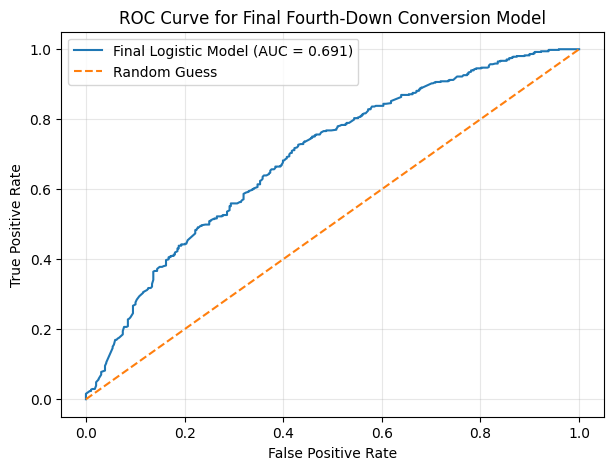

In [45]:
#| label: fig-roc-curve
#| fig-cap: "ROC curve for the final feature-engineered logistic regression model on the future-season test set."
from sklearn.metrics import roc_curve, auc as sklearn_auc
fpr, tpr, thresholds = roc_curve(y_test_final, final_pred_prob)
roc_auc = sklearn_auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Final Logistic Model (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Final Fourth-Down Conversion Model")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

@fig-roc-curve shows that the final model separates successful and unsuccessful attempts moderately well. An ROC-AUC of about 0.691 indicates useful signal, but the curve is still far from the upper-left corner, so the model should support coaching decisions rather than replace them.

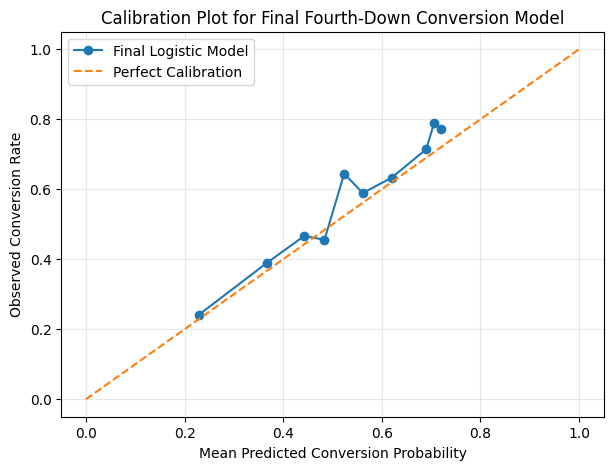

In [46]:
#| label: fig-calibration-curve
#| fig-cap: "Calibration plot for the final feature-engineered logistic regression model on the future-season test set."
prob_true, prob_pred = calibration_curve(
    y_test_final,
    final_pred_prob,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 5))
plt.plot(prob_pred, prob_true, marker="o", label="Final Logistic Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")

plt.xlabel("Mean Predicted Conversion Probability")
plt.ylabel("Observed Conversion Rate")
plt.title("Calibration Plot for Final Fourth-Down Conversion Model")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

@fig-calibration-curve shows that the final model is reasonably well calibrated overall, with the curve staying fairly close to the 45-degree reference line. Small departures remain in some probability ranges, so the output should be interpreted as a useful estimate rather than an exact probability.

## Discussion

The report points to three main findings. First, the exploratory pattern in @fig-eda-conversion-rate shows that yards to go is the clearest single driver of fourth-down success, which explains why grouped distance features remained useful throughout the modeling process. Second, @tbl-final-model-comparison shows that the feature-engineered logistic regression without team identifiers produced the best out-of-sample probability estimates. Third, the final diagnostics in @fig-roc-curve and @fig-calibration-curve show a model that is useful but still moderate in both discrimination and calibration.

A major strength of the final model is interpretability. Logistic regression is easier to explain than random forest or gradient boosting, which matters in a decision-support setting where coaches need to understand why the model is recommending caution or aggression. The selected features also make football sense: red-zone status, goal-to-go situations, grouped distance, field position, and pass-distance interactions all correspond to meaningful strategic differences on fourth down.

The model also appears to generalize better when team identifiers are excluded. That result is reasonable because team-level tendencies can change substantially across seasons as rosters, injuries, and coaching staffs change. Removing those identifiers produced a model that is slightly simpler and more stable when the evaluation target is future games rather than the same seasons used for training.

At the same time, the model has clear limitations. Its ROC-AUC is only moderate, and its Brier score is not low enough to treat the predicted probabilities as highly precise. Many relevant football variables are absent from the dataset, including score differential, quarter, time remaining, weather, personnel groupings, quarterback quality, and the exact play design. Those missing inputs likely explain why even the best model still leaves substantial uncertainty.

For practical use, this model should be treated as one component of a broader decision system rather than as an automatic decision-maker. A real fourth-down recommendation would need to combine conversion probability with expected points or win probability so that the value of going for it can be compared with punting or attempting a field goal in the same game situation.

## Conclusion

This project developed a fourth-down conversion probability model using NFL play data from 2019 through early 2025. The final choice was a feature-engineered logistic regression model without team identifiers because it delivered the best combination of log loss, Brier score, and reasonable calibration on the future-season test set.

The final model is useful as a prototype decision-support tool. It improves on a naive baseline, captures important football structure, and produces probabilities that are informative enough to support discussion. However, it should be viewed as a conversion-probability component inside a larger strategy framework rather than as a complete fourth-down decision model.

In [47]:
from joblib import dump
dump(final_model, "Football.joblib", compress=9)

['Football.joblib']